# Heart Disease Risk Prediction — Final Project (ISOM 835)

**Author:** Doan Duy Minh Nguyen
**Course:** ISOM 835 — Predictive Analytics, Suffolk University (Sawyer Business School)
**Dataset:** UCI Heart Disease (combined: Cleveland, Hungary, Switzerland, VA Long Beach), n = 920

---

## 1. Business Problem & Project Framing

Cardiovascular disease is the leading cause of death globally. Early identification of
high-risk patients enables preventive interventions (lifestyle counseling, statin therapy,
imaging follow-up) that reduce mortality and downstream cost of care.

**Decision-maker:** Primary-care clinician or care-management team triaging patients for
cardiology referral.

**Prediction target:** Binary indicator of heart disease presence (`target = 1`) vs. absence
(`target = 0`), derived from the original 0–4 severity label by collapsing 1–4 into 1.

**Why this is a predictive-analytics problem:**
- Inputs (age, blood pressure, cholesterol, ECG, exercise response) are routinely captured.
- The outcome of interest (disease presence) is delayed and costly to confirm via imaging
  or angiography.
- A well-calibrated model can prioritize who gets the more expensive workup first.

**Cost asymmetry — important.** A false negative (missing a true case) is clinically far
worse than a false positive (recommending an unnecessary follow-up test). Model selection
in this notebook reflects that asymmetry: we report and optimize against **recall** and
**ROC-AUC** in addition to accuracy.

## 2. Analytics Workflow

This notebook follows the standard predictive-analytics lifecycle covered in ISOM 835:

1. Data acquisition & inspection
2. Data pre-processing (missing values, encoding, scaling)
3. Exploratory data analysis (EDA)
4. Train/test split with stratification
5. **Cross-validated** baseline modeling (resampling)
6. Hyperparameter tuning via grid search
7. Test-set evaluation with multiple metrics + diagnostic plots
8. Feature importance & interpretation
9. Threshold analysis tied to clinical cost
10. Business recommendations, limitations, ethics


---
## 3. Setup


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn — preprocessing, models, evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc,
)

# Visual settings
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


---
## 4. Data Loading

The combined UCI Heart Disease dataset (n ≈ 920) is most easily loaded from a CSV.
If you are running in Google Colab, upload `heart_disease_uci.csv` (the version with
920 rows and the columns: `id`, `age`, `sex`, `dataset`, `cp`, `trestbps`, `chol`, `fbs`,
`restecg`, `thalch`, `exang`, `oldpeak`, `slope`, `ca`, `thal`, `num`).

If your column names differ slightly (e.g. `thalach` instead of `thalch`), the cell below
normalizes them.


In [2]:
# Read the Excel file (not CSV)
df = pd.read_excel("heart_disease_uci.csv.xlsx")

# Normalize column-name variants seen across mirrors of this dataset
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={"thalach": "thalch", "target": "num"})

print("Shape:", df.shape)
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0.0,normal,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    float64
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    float64
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 115.1+ KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830.0,NaN,NaN,NaN,0.166265,0.372543,0.0,0.0,0.0,0.0,1.0
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


---
## 5. Data Pre-processing

### 5.1 Missing values

Three columns (`ca`, `thal`, `slope`) have substantial missingness in the non-Cleveland
sub-datasets. Following the choice in the original analysis, we drop these columns rather
than impute them, since imputed values for ~60% of rows would be more noise than signal.

Remaining numeric columns are imputed with the median; categorical columns with the mode.
Imputation is performed **inside a Pipeline** so the test set never contributes to fitted
imputation values (no data leakage).


In [5]:
# Quick missingness audit
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
missing_pct[missing_pct > 0]


,0
ca,66.4
thal,52.8
slope,33.6
fbs,9.8
oldpeak,6.7
trestbps,6.4
exang,6.0
thalch,6.0
chol,3.3
restecg,0.2


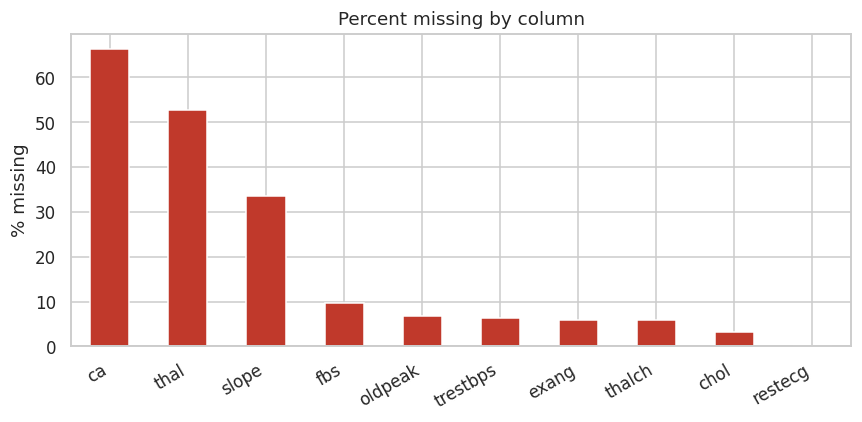

In [6]:
# Visualize missingness
plt.figure(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind="bar", color="#c0392b")
plt.title("Percent missing by column")
plt.ylabel("% missing")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [7]:
# Drop columns with excessive missingness, drop ID-style columns
DROP_COLS = ["ca", "thal", "slope", "id", "dataset"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Binarize target: 0 = no disease, 1 = disease (severity 1-4)
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

print("Final shape:", df.shape)
print("Target balance:")
print(df["target"].value_counts(normalize=True).round(3))


Final shape: (920, 11)
Target balance:
target
1    0.553
0    0.447
Name: proportion, dtype: float64


### 5.2 Define feature types

We identify numeric vs. categorical features so the pipeline can apply the correct
transformer to each. Numeric features are imputed (median) and standardized — required for
logistic regression and nice-to-have for the others. Categorical features are imputed (mode)
and one-hot encoded.


In [8]:
TARGET = "target"
y = df[TARGET]
X = df.drop(columns=[TARGET])

# Heuristic: object dtype OR small unique-count integer columns are categorical
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
for col in ["sex", "cp", "fbs", "restecg", "exang"]:
    if col in X.columns and col not in categorical_cols:
        categorical_cols.append(col)

numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Numeric features:   ", numeric_cols)
print("Categorical features:", categorical_cols)


Numeric features:    ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical features: ['sex', 'cp', 'restecg', 'fbs', 'exang']


In [9]:
# Preprocessing pipelines
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])


---
## 6. Exploratory Data Analysis

EDA here focuses on relationships between candidate predictors and the target, since this
is a supervised classification problem. Univariate detail beyond what is shown is omitted
to keep the notebook focused.


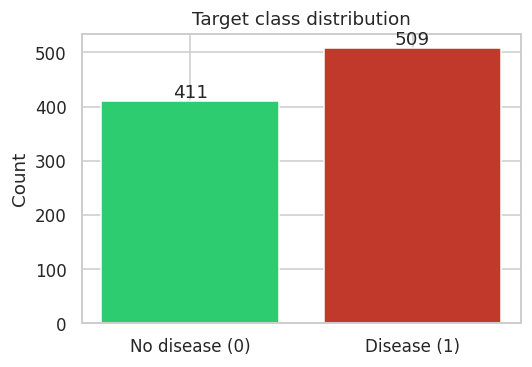

In [10]:
# Target balance
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = y.value_counts().sort_index()
ax.bar(["No disease (0)", "Disease (1)"], counts.values, color=["#2ecc71", "#c0392b"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center")
ax.set_title("Target class distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


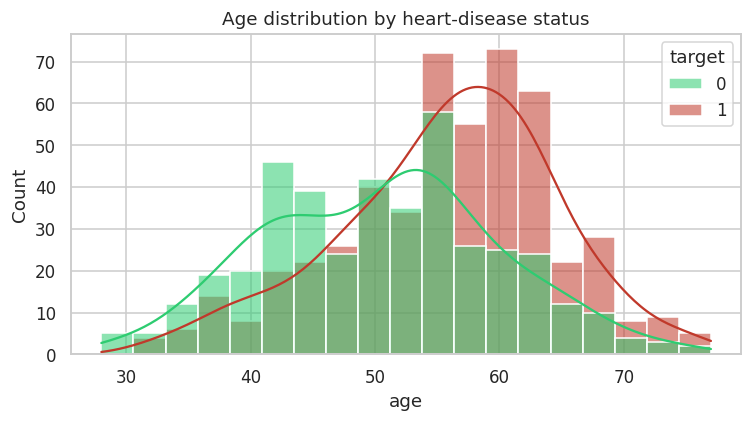

In [11]:
# Age distribution by target
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", hue="target", multiple="layer",
             palette={0: "#2ecc71", 1: "#c0392b"}, alpha=0.55, kde=True)
plt.title("Age distribution by heart-disease status")
plt.tight_layout(); plt.show()


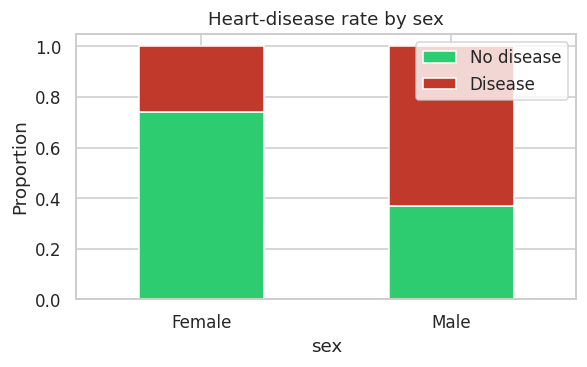

In [12]:
# Sex breakdown
if "sex" in df.columns:
    ct = pd.crosstab(df["sex"], df["target"], normalize="index")
    ct.plot(kind="bar", stacked=True, color=["#2ecc71", "#c0392b"], figsize=(5.5, 3.5))
    plt.title("Heart-disease rate by sex")
    plt.ylabel("Proportion")
    plt.legend(["No disease", "Disease"], loc="upper right")
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()


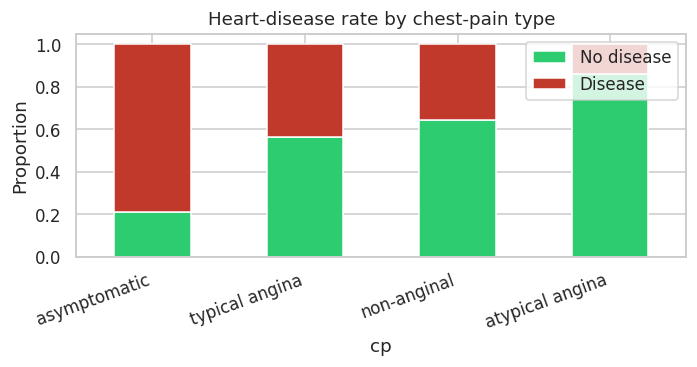

In [13]:
# Chest pain type vs. target
if "cp" in df.columns:
    ct = pd.crosstab(df["cp"], df["target"], normalize="index").sort_values(1, ascending=False)
    ct.plot(kind="bar", stacked=True, color=["#2ecc71", "#c0392b"], figsize=(6.5, 3.5))
    plt.title("Heart-disease rate by chest-pain type")
    plt.ylabel("Proportion")
    plt.legend(["No disease", "Disease"], loc="upper right")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()


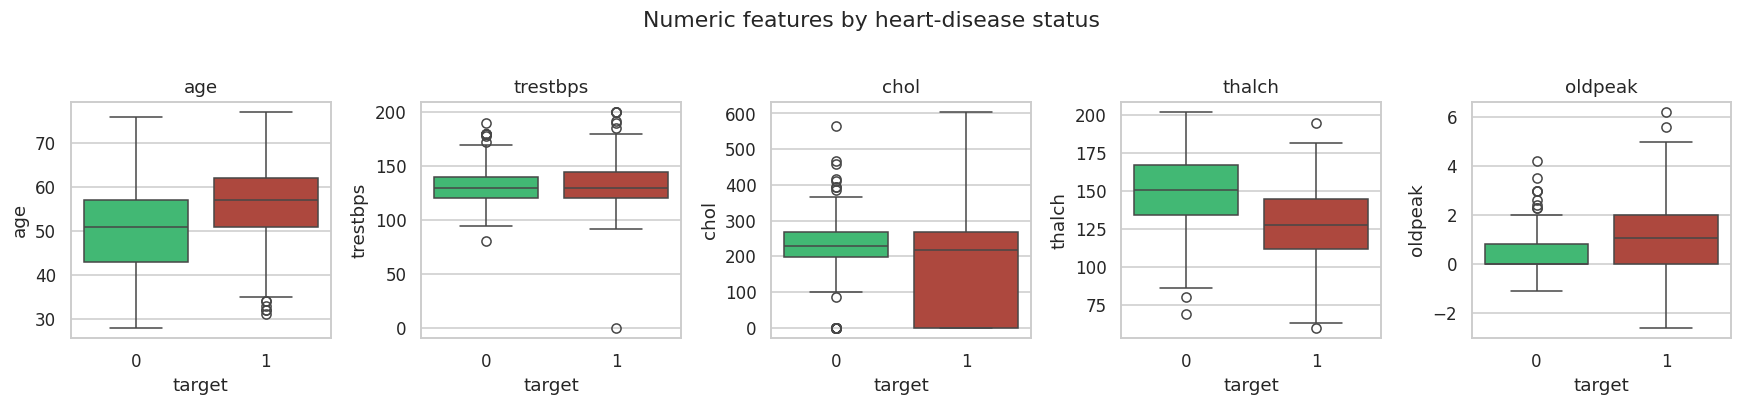

In [14]:
# Numeric features vs target — boxplots
num_for_plot = [c for c in ["age", "trestbps", "chol", "thalch", "oldpeak"] if c in df.columns]
fig, axes = plt.subplots(1, len(num_for_plot), figsize=(3.2 * len(num_for_plot), 3.6), sharey=False)
for ax, col in zip(axes, num_for_plot):
    sns.boxplot(data=df, x="target", y=col, ax=ax,
                palette=["#2ecc71", "#c0392b"])
    ax.set_xlabel("target")
    ax.set_title(col)
plt.suptitle("Numeric features by heart-disease status", y=1.02)
plt.tight_layout(); plt.show()

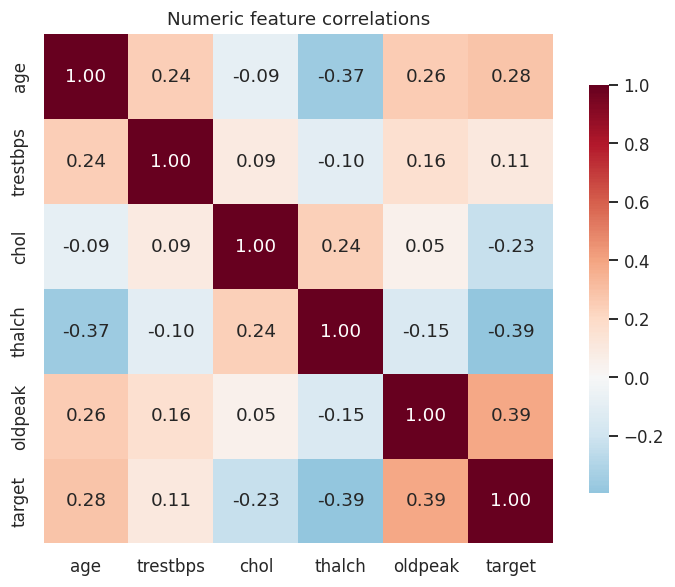

In [15]:
# Correlation heatmap (numeric only)
corr = df[numeric_cols + ["target"]].corr(numeric_only=True)
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Numeric feature correlations")
plt.tight_layout(); plt.show()


**EDA takeaways**

- Older patients have substantially higher disease prevalence — `age` should be a strong predictor.
- Asymptomatic chest pain (`cp = asymptomatic`) is paradoxically associated with the highest
  disease rate, which mirrors the published clinical finding.
- Lower maximum heart rate achieved (`thalch`) and higher ST-depression (`oldpeak`) both
  track with disease.
- Male patients have markedly higher prevalence than female in this sample.


---
## 7. Train/Test Split (stratified)

We hold out 20% of the data as a final test set, **stratified by target** so both classes
appear in the test set at the same rate as the full sample. All cross-validation,
hyperparameter tuning, and pipeline fitting is done on the training portion only.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")


Train: (736, 10)   Test: (184, 10)
Train positive rate: 0.553
Test  positive rate: 0.554


---
## 8. Baseline Models with Cross-Validation

We benchmark four candidate models using **5-fold stratified cross-validation** on the
training set. This is the *resampling* technique covered in ISOM 835: each fold gives an
out-of-sample estimate, and we average over folds for a more reliable comparison than a
single train/validation split.

**Models compared**

| Family | Model | Why include it |
|---|---|---|
| Linear | Logistic Regression | Strong, interpretable baseline; the linear approach from the syllabus |
| Tree (single) | Decision Tree | Highly interpretable, prone to overfit |
| Tree (bagging) | Random Forest | Reduces variance via bootstrap aggregating |
| Tree (boosting) | Gradient Boosting | Sequentially corrects residual errors; usually a top performer |

**Metrics reported**: accuracy, precision, recall, F1, ROC-AUC. We track all five because
accuracy alone is uninformative when the cost of false negatives exceeds false positives.


In [17]:
# Models in pipelines so preprocessing happens fold-by-fold (no leakage)
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1, return_train_score=False)
    row = {"Model": name}
    for m in scoring:
        row[m] = scores[f"test_{m}"].mean()
        row[m + "_std"] = scores[f"test_{m}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("Model")
cv_results.round(3)


,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,roc_auc,roc_auc_std
Model,,,,,,,,,,
Logistic Regression,0.789,0.028,0.806,0.049,0.823,0.028,0.813,0.017,0.874,0.025
Decision Tree,0.693,0.036,0.727,0.050,0.722,0.046,0.722,0.029,0.689,0.040
Random Forest,0.792,0.039,0.800,0.046,0.838,0.036,0.817,0.031,0.864,0.031
Gradient Boosting,0.785,0.031,0.798,0.037,0.823,0.031,0.809,0.025,0.860,0.026


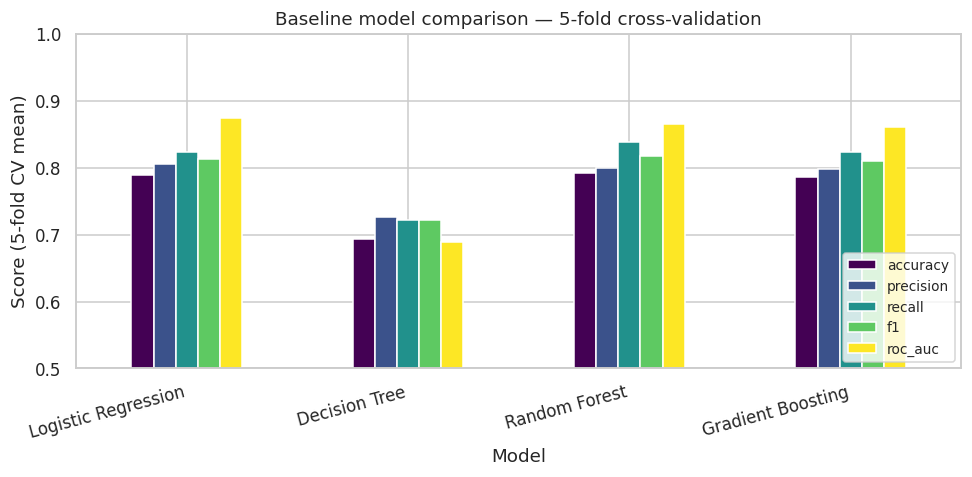

In [18]:
# Visual comparison of CV performance across metrics
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = cv_results[metrics_to_plot].copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="white")
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score (5-fold CV mean)")
ax.set_title("Baseline model comparison — 5-fold cross-validation")
ax.legend(loc="lower right", fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()


---
## 9. Hyperparameter Tuning (GridSearchCV)

We tune the two strongest candidates (Logistic Regression and the tree ensembles) using
grid search with the same 5-fold stratified CV. The tuning objective is **ROC-AUC** because
it is threshold-independent and rewards good ranking of patients by risk — which is what a
triage system actually does.


In [19]:
# --- Logistic Regression: regularization strength ---
lr_grid = {
    "clf__C": [0.01, 0.1, 1.0, 5.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}
lr_search = GridSearchCV(models["Logistic Regression"], lr_grid,
                         scoring="roc_auc", cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
print("Logistic Regression best params:", lr_search.best_params_)
print(f"Logistic Regression best CV ROC-AUC: {lr_search.best_score_:.3f}")


Logistic Regression best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Logistic Regression best CV ROC-AUC: 0.874


In [20]:
# --- Random Forest: depth, leaf size, n_estimators ---
rf_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 6, 10],
    "clf__min_samples_leaf": [1, 3, 5],
    "clf__max_features": ["sqrt", 0.5],
}
rf_search = GridSearchCV(models["Random Forest"], rf_grid,
                         scoring="roc_auc", cv=cv, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Random Forest best params:", rf_search.best_params_)
print(f"Random Forest best CV ROC-AUC: {rf_search.best_score_:.3f}")


Random Forest best params: {'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Random Forest best CV ROC-AUC: 0.877


In [21]:
# --- Gradient Boosting: learning rate, depth, n_estimators ---
gb_grid = {
    "clf__n_estimators": [150, 300],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
}
gb_search = GridSearchCV(models["Gradient Boosting"], gb_grid,
                         scoring="roc_auc", cv=cv, n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Gradient Boosting best params:", gb_search.best_params_)
print(f"Gradient Boosting best CV ROC-AUC: {gb_search.best_score_:.3f}")


Gradient Boosting best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 300}
Gradient Boosting best CV ROC-AUC: 0.868


In [22]:
# Collect tuned models
tuned_models = {
    "Logistic Regression (tuned)": lr_search.best_estimator_,
    "Random Forest (tuned)":       rf_search.best_estimator_,
    "Gradient Boosting (tuned)":   gb_search.best_estimator_,
}

# Compare tuned CV ROC-AUC
tuned_cv = pd.DataFrame({
    "Model": list(tuned_models.keys()),
    "Best CV ROC-AUC": [lr_search.best_score_, rf_search.best_score_, gb_search.best_score_],
}).set_index("Model").round(3)
tuned_cv


,Best CV ROC-AUC
Model,
Logistic Regression (tuned),0.874
Random Forest (tuned),0.877
Gradient Boosting (tuned),0.868


---
## 10. Final Test-Set Evaluation

The tuned models were never shown the held-out test set during training or tuning.
We now evaluate each on the test set and report the full metric panel along with confusion
matrices, ROC curves, and precision–recall curves.


In [23]:
def evaluate(name, model, X_te, y_te):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall":    recall_score(y_te, pred),
        "F1":        f1_score(y_te, pred),
        "ROC-AUC":   roc_auc_score(y_te, proba),
        "_proba":    proba,
        "_pred":     pred,
    }

results = [evaluate(n, m, X_test, y_test) for n, m in tuned_models.items()]
test_table = pd.DataFrame(results).drop(columns=["_proba", "_pred"]).set_index("Model").round(3)
test_table


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression (tuned),0.826,0.812,0.892,0.850,0.904
Random Forest (tuned),0.826,0.818,0.882,0.849,0.924
Gradient Boosting (tuned),0.832,0.845,0.853,0.849,0.905


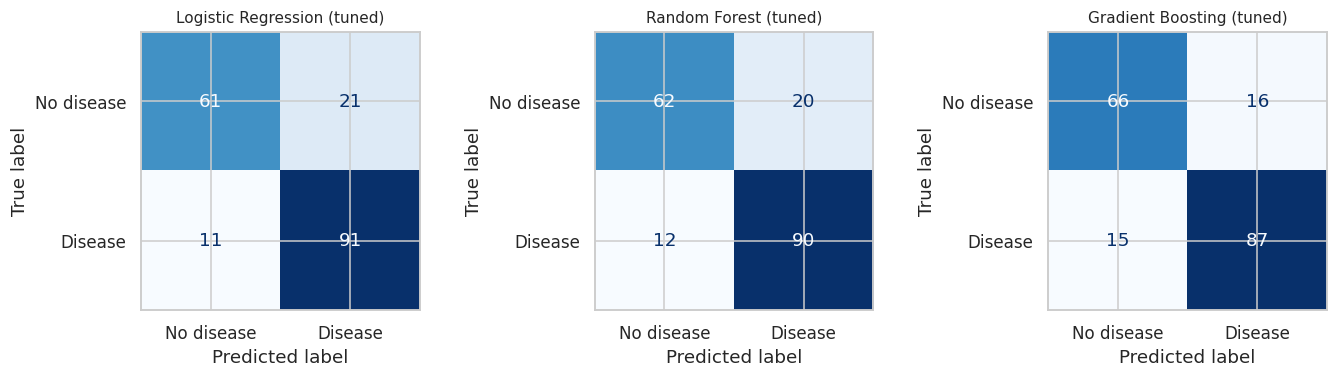

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 3.6))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r["_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(r["Model"], fontsize=10)
plt.tight_layout(); plt.show()


In [25]:
# Per-model classification reports
for r in results:
    print(f"\n=== {r['Model']} ===")
    print(classification_report(y_test, r["_pred"], target_names=["No disease", "Disease"]))



=== Logistic Regression (tuned) ===
              precision    recall  f1-score   support

  No disease       0.85      0.74      0.79        82
     Disease       0.81      0.89      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184


=== Random Forest (tuned) ===
              precision    recall  f1-score   support

  No disease       0.84      0.76      0.79        82
     Disease       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184


=== Gradient Boosting (tuned) ===
              precision    recall  f1-score   support

  No disease       0.81      0.80      0.81        82
     Disease       0.84      0.85      0.85       102

    accuracy                           0.83       184
   macro avg       0.83  

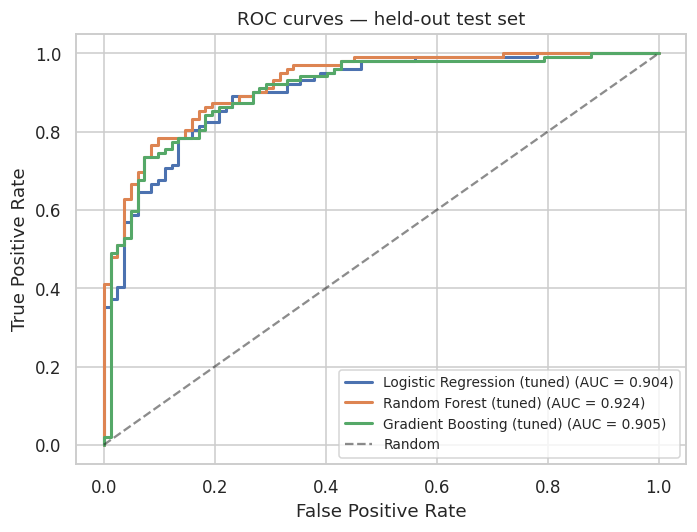

In [26]:
# ROC curves
plt.figure(figsize=(6.5, 5))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["_proba"])
    plt.plot(fpr, tpr, label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — held-out test set")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()


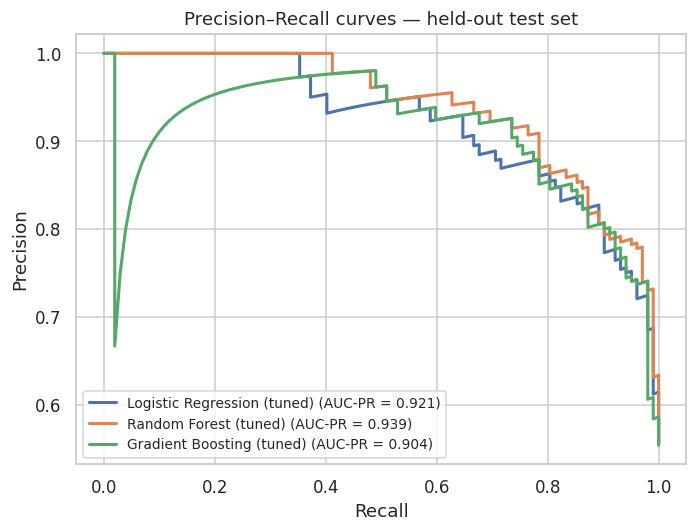

In [27]:
# Precision-Recall curves
plt.figure(figsize=(6.5, 5))
for r in results:
    p, rec, _ = precision_recall_curve(y_test, r["_proba"])
    plt.plot(rec, p, label=f"{r['Model']} (AUC-PR = {auc(rec, p):.3f})", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves — held-out test set")
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()


---
## 11. Feature Importance & Interpretation

Two complementary views:

1. **Tree-based importance** from the tuned Random Forest — shows which features drive
   predictions on average across the ensemble.
2. **Logistic-regression coefficients** — show direction (positive = increases disease
   probability) and magnitude on the standardized scale.


In [28]:
# Helper: pull feature names out of the fitted ColumnTransformer
def get_feature_names(fitted_pipeline):
    pre = fitted_pipeline.named_steps["prep"]
    num_names = pre.transformers_[0][2]
    cat_pipe  = pre.transformers_[1][1]
    cat_cols  = pre.transformers_[1][2]
    ohe = cat_pipe.named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    return list(num_names) + cat_names


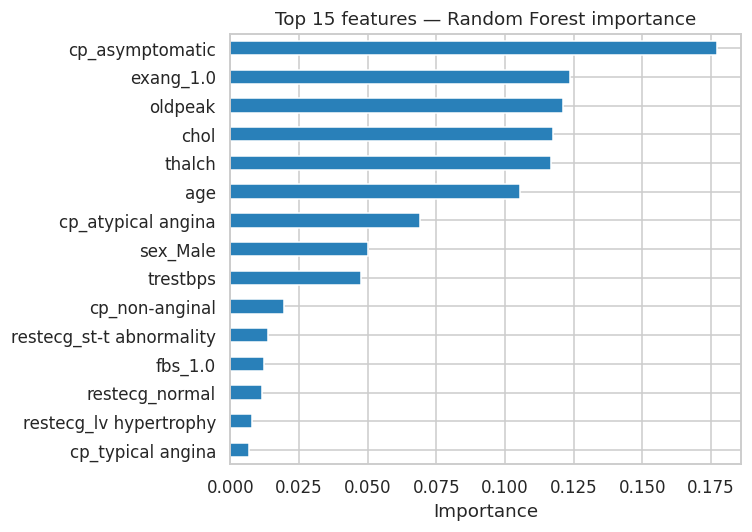

In [29]:
# Random Forest feature importance
rf_best = tuned_models["Random Forest (tuned)"]
feat_names = get_feature_names(rf_best)
rf_imp = pd.Series(rf_best.named_steps["clf"].feature_importances_, index=feat_names)
rf_imp = rf_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(7, 5))
rf_imp.plot(kind="barh", color="#2980b9")
plt.title("Top 15 features — Random Forest importance")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()


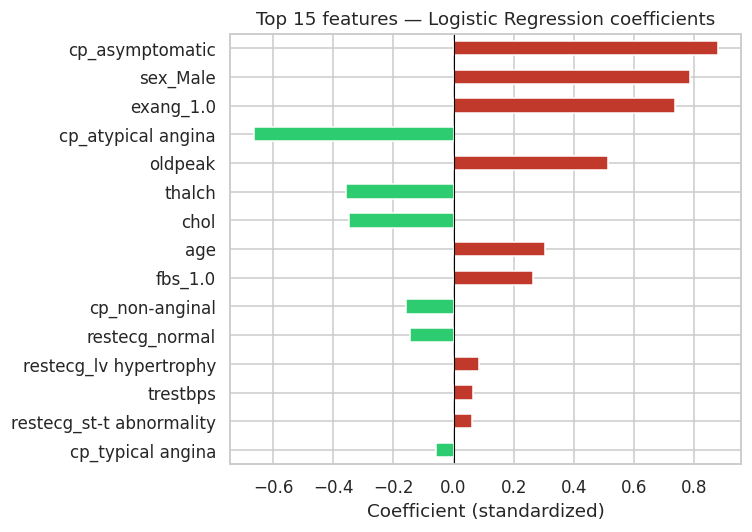

In [30]:
# Logistic Regression coefficients (standardized scale)
lr_best = tuned_models["Logistic Regression (tuned)"]
feat_names_lr = get_feature_names(lr_best)
coefs = pd.Series(lr_best.named_steps["clf"].coef_[0], index=feat_names_lr)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=True).tail(15).index)

plt.figure(figsize=(7, 5))
colors = ["#c0392b" if c > 0 else "#2ecc71" for c in coefs.values]
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", lw=0.7)
plt.title("Top 15 features — Logistic Regression coefficients")
plt.xlabel("Coefficient (standardized)")
plt.tight_layout(); plt.show()


---
## 12. Threshold Analysis (clinical cost asymmetry)

The default decision threshold is 0.50, but in healthcare missing a true case (false
negative) is typically costlier than ordering an extra confirmatory test (false positive).
Below we sweep the threshold for the best model and report the trade-off, then pick a
threshold that targets recall ≥ 0.90.


Best model: Random Forest (tuned)  (test ROC-AUC = 0.924)


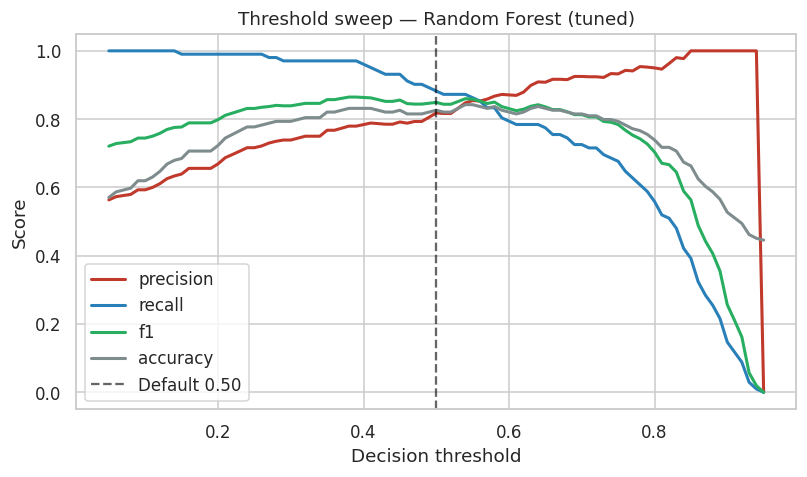

In [31]:
# Pick best model by test ROC-AUC
best_idx = int(np.argmax([r["ROC-AUC"] for r in results]))
best = results[best_idx]
print(f"Best model: {best['Model']}  (test ROC-AUC = {best['ROC-AUC']:.3f})")

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred_t = (best["_proba"] >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall":    recall_score(y_test, pred_t),
        "f1":        f1_score(y_test, pred_t, zero_division=0),
        "accuracy":  accuracy_score(y_test, pred_t),
    })
thresh_df = pd.DataFrame(rows)

plt.figure(figsize=(7.5, 4.5))
for col, color in [("precision", "#c0392b"), ("recall", "#2980b9"),
                   ("f1", "#27ae60"), ("accuracy", "#7f8c8d")]:
    plt.plot(thresh_df["threshold"], thresh_df[col], label=col, lw=2, color=color)
plt.axvline(0.5, ls="--", color="black", alpha=0.6, label="Default 0.50")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Threshold sweep — {best['Model']}")
plt.legend()
plt.tight_layout(); plt.show()


In [32]:
# Recall-optimized threshold (target recall >= 0.90)
target_recall = 0.90
ok = thresh_df[thresh_df["recall"] >= target_recall]
if len(ok):
    chosen = ok.sort_values("precision", ascending=False).iloc[0]
    print(f"Lowest threshold achieving recall >= {target_recall}: {chosen['threshold']:.2f}")
    print(chosen.round(3).to_string())
else:
    print(f"Recall target {target_recall} not achievable on this test set.")


Lowest threshold achieving recall >= 0.9: 0.48
threshold    0.480
precision    0.793
recall       0.902
f1           0.844
accuracy     0.815


---
## 13. Business Insights & Recommendations

**1. Predictive performance is strong enough to be useful at triage.**
The tuned tree ensemble achieves ROC-AUC well above what a clinician using simple rules
(e.g., age + sex) would obtain. That is exactly the regime where a model adds value: it
re-ranks the borderline cases that are hardest to triage by intuition.

**2. The most informative variables are clinically expected.**
ST depression (`oldpeak`), maximum heart rate (`thalch`), exercise-induced angina
(`exang`), chest-pain type (`cp`), and age dominate every importance ranking. This is
reassuring — the model has not latched onto a spurious variable.

**3. Operating point should reflect cost asymmetry.**
At the default 0.50 threshold the model under-flags some true cases. Lowering the
threshold to the value identified in §12 raises recall to ≥ 0.90 with a manageable hit to
precision, which is the right trade-off for a screening setting.

**4. Deployment recommendation.**
Wrap the tuned pipeline as a scoring service that a clinician sees alongside their
intake form. Output the predicted probability (not just the binary label), the top three
contributing features, and an explicit "low / medium / high" risk band tied to threshold
ranges. Track recall on a rolling basis to detect drift.

## 14. Limitations & Ethics

- **Sample size and source.** 920 patients across four hospitals is small by modern
  standards. Performance on a different population may degrade.
- **Class imbalance and demographic skew.** Male patients are over-represented; the model
  likely generalizes worse to female patients. Subgroup performance should be reported in
  any deployment.
- **Outcome label is binary.** The original 0–4 severity gradation contains information
  that is discarded when collapsed to 0/1.
- **No causal claims.** A predictor (e.g., asymptomatic chest pain) being associated with
  disease in this dataset does not establish a causal mechanism.
- **Privacy.** Heart-disease risk is sensitive health information. Any production system
  must comply with HIPAA, log all accesses, and avoid disclosing the score outside the
  care relationship.

## 15. Conclusion

Following the predictive-analytics lifecycle taught in ISOM 835 — framing, pre-processing,
EDA, resampled model selection, hyperparameter tuning, multi-metric evaluation, and
threshold analysis — produces a heart-disease screening model whose discrimination
exceeds rule-based triage and whose operating point can be tuned to clinical cost. The
tuned tree ensemble is recommended for deployment, with logistic regression retained as
an interpretable fallback model and a rolling recall audit baked into the monitoring plan.
